# 02 - 逻辑回归（分类）

> 配套教程：`03_machine_learning/02_logistic_regression.py`

逻辑回归虽然名字里有“回归”，但它实际上是一个分类算法。它是理解神经网络的重要基石：线性层、Sigmoid/Softmax、交叉熵、梯度下降都会在这里出现。

## 本 Notebook 概览

| 章节 | 内容 | 关键概念 |
|------|------|----------|
| 1 | 从线性回归到逻辑回归 | 线性打分、Sigmoid、概率阈值 |
| 2 | Sigmoid 函数深入理解 | S 形曲线、导数、饱和区、数值稳定 |
| 3 | 交叉熵损失函数 | BCE、为什么不用 MSE、错误自信惩罚 |
| 4 | 从零实现逻辑回归 | 前向传播、梯度、参数更新、训练曲线 |
| 5 | 决策边界 | $w_1x_1+w_2x_2+b=0$、阈值调整 |
| 6 | 多类分类 Softmax 回归 | 多类别概率、one-hot、多类交叉熵 |
| 7 | 非线性数据的局限性 | 月牙数据、线性边界不足、为什么需要神经网络 |

**学习目标**：不仅会运行代码，还能说清楚每个公式在做什么、每段代码对应训练流程中的哪一步。

In [1]:
# 环境设置
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager

from sklearn.datasets import make_classification, make_moons, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression


def configure_chinese_font():
    preferred_fonts = [
        "Noto Sans CJK SC", "Noto Sans CJK JP", "Source Han Sans SC",
        "WenQuanYi Zen Hei", "WenQuanYi Micro Hei", "SimHei",
        "Microsoft YaHei", "PingFang SC", "Arial Unicode MS",
    ]
    available_fonts = {font.name for font in font_manager.fontManager.ttflist}
    for font_name in preferred_fonts:
        if font_name in available_fonts:
            plt.rcParams["font.sans-serif"] = [font_name, "DejaVu Sans"]
            plt.rcParams["font.family"] = "sans-serif"
            print(f"Matplotlib 中文字体: {font_name}")
            return font_name
    print("未检测到可用中文字体，中文图表可能显示为方框。")
    print("Linux 可安装：sudo apt-get install fonts-noto-cjk 或 fonts-wqy-zenhei")
    return None


CHINESE_FONT = configure_chinese_font()
plt.rcParams["axes.unicode_minus"] = False
np.set_printoptions(precision=4, suppress=True)
np.random.seed(42)

print("环境准备完毕")

Matplotlib 中文字体: Noto Sans CJK JP
环境准备完毕


## 1. 从线性回归到逻辑回归

线性回归输出连续值，例如房价、温度、销量：

$$\hat y = wx + b$$

但分类问题需要输出“属于某一类的概率”。例如：

- 输入：邮件特征；输出：是垃圾邮件的概率。
- 输入：用户行为；输出：是否会点击广告的概率。
- 输入：医学指标；输出：是否患病的概率。

线性模型给出的 $z=wx+b$ 可以理解为“证据强度”，但 $z$ 可能是任意实数，不是概率。逻辑回归在 $z$ 后面接一个 Sigmoid 函数：

$$p=\sigma(z)=\frac{1}{1+e^{-z}}$$

Sigmoid 会把任意实数压缩到 $(0,1)$，于是 $p$ 可以解释为正类概率。

默认分类规则：

- $p \ge 0.5$：预测为正类 1。
- $p < 0.5$：预测为负类 0。

> 初学者要特别注意：模型先输出概率，再根据阈值转成类别。类别不是模型的第一输出。

In [2]:
def sigmoid(z):
    z = np.clip(z, -500, 500)  # 防止 exp 溢出
    return 1 / (1 + np.exp(-z))


# 手算式小例子：两个特征、两个权重、一个偏置
x = np.array([2.0, -1.0])
w = np.array([1.5, -0.8])
b = -0.2
z_value = x @ w + b
p_value = sigmoid(z_value)

print("样本 x:", x)
print("权重 w:", w)
print("偏置 b:", b)
print(f"线性打分 z = x @ w + b = {z_value:.4f}")
print(f"正类概率 p = sigmoid(z) = {p_value:.4f}")
print("预测类别:", 1 if p_value >= 0.5 else 0)

样本 x: [ 2. -1.]
权重 w: [ 1.5 -0.8]
偏置 b: -0.2
线性打分 z = x @ w + b = 3.6000
正类概率 p = sigmoid(z) = 0.9734
预测类别: 1


### 权重符号怎么理解

在线性打分 $z=w_1x_1+w_2x_2+\cdots+b$ 中：

- $w_j>0$：第 $j$ 个特征越大，越支持正类。
- $w_j<0$：第 $j$ 个特征越大，越支持负类。
- $|w_j|$ 越大：在特征尺度相近时，该特征影响越强。

这只是“模型里的关联”，不要直接解释成因果关系。例如“点击次数多”可能提高购买概率，但不代表强行制造点击次数就一定导致购买。

In [3]:
w_demo = np.array([2.0, -1.5])
b_demo = 0.0
cases = {
    "基准样本": np.array([0.0, 0.0]),
    "特征1增加": np.array([1.0, 0.0]),
    "特征2增加": np.array([0.0, 1.0]),
    "两个特征都增加": np.array([1.0, 1.0]),
}

for name, sample in cases.items():
    z_case = sample @ w_demo + b_demo
    print(f"{name:<10} x={sample}, z={z_case:+.2f}, p={sigmoid(z_case):.4f}")

基准样本       x=[0. 0.], z=+0.00, p=0.5000
特征1增加      x=[1. 0.], z=+2.00, p=0.8808
特征2增加      x=[0. 1.], z=-1.50, p=0.1824
两个特征都增加    x=[1. 1.], z=+0.50, p=0.6225


## 2. Sigmoid 函数深入理解

Sigmoid 的性质：

- 输出范围是 $(0,1)$。
- $\sigma(0)=0.5$。
- $z$ 越大，输出越接近 1。
- $z$ 越小，输出越接近 0。
- 导数是 $\sigma'(z)=\sigma(z)(1-\sigma(z))$。

导数告诉我们：当 $z$ 接近 0 时，模型对参数变化最敏感；当 $z$ 非常大或非常小时，Sigmoid 进入饱和区，导数接近 0。

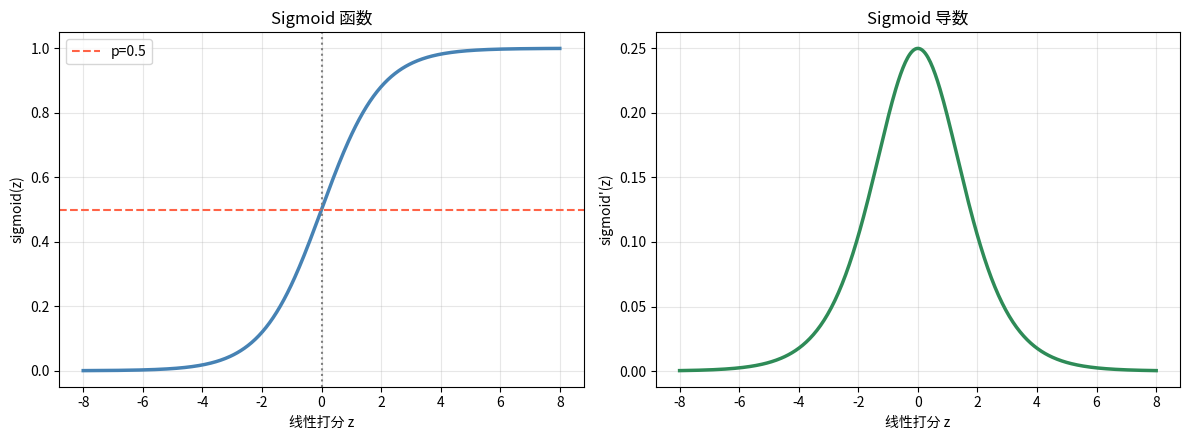

z=-4 -> p=0.0180, derivative=0.0177
z=-1 -> p=0.2689, derivative=0.1966
z=+0 -> p=0.5000, derivative=0.2500
z=+1 -> p=0.7311, derivative=0.1966
z=+4 -> p=0.9820, derivative=0.0177


In [4]:
z = np.linspace(-8, 8, 400)
p = sigmoid(z)
derivative = p * (1 - p)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(z, p, linewidth=2.5, color="steelblue")
axes[0].axhline(0.5, color="tomato", linestyle="--", label="p=0.5")
axes[0].axvline(0, color="gray", linestyle=":")
axes[0].set_xlabel("线性打分 z")
axes[0].set_ylabel("sigmoid(z)")
axes[0].set_title("Sigmoid 函数")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(z, derivative, linewidth=2.5, color="seagreen")
axes[1].set_xlabel("线性打分 z")
axes[1].set_ylabel("sigmoid'(z)")
axes[1].set_title("Sigmoid 导数")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

for value in [-4, -1, 0, 1, 4]:
    print(f"z={value:+.0f} -> p={sigmoid(value):.4f}, derivative={sigmoid(value)*(1-sigmoid(value)):.4f}")

## 3. 交叉熵损失函数

分类问题通常不用 MSE，而用交叉熵。二分类交叉熵 Binary Cross-Entropy：

$$L=-\frac{1}{n}\sum_i \left[y_i\log(p_i)+(1-y_i)\log(1-p_i)\right]$$

分两种情况看：

| 真实标签 | 损失 | 预测正确时 | 预测错误且自信时 |
|----------|------|------------|------------------|
| $y=1$ | $-\log(p)$ | $p\to1$，loss 接近 0 | $p\to0$，loss 很大 |
| $y=0$ | $-\log(1-p)$ | $p\to0$，loss 接近 0 | $p\to1$，loss 很大 |

直觉：交叉熵特别惩罚“错误且自信”的预测。例如真实是正类，但模型只给 0.01 的概率，损失会非常大。

逻辑回归配合交叉熵后，梯度形式很简洁：

$$\frac{\partial L}{\partial \mathbf{w}}=\frac{1}{n}X^T(p-y),\qquad
\frac{\partial L}{\partial b}=\frac{1}{n}\sum_i(p_i-y_i)$$

这里的 $p-y$ 可以理解成“概率误差”。

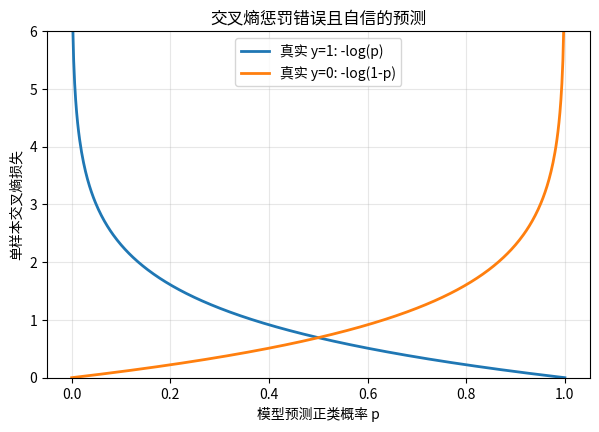

y=1, p=0.9 -> loss=0.1054
y=1, p=0.1 -> loss=2.3026
y=0, p=0.1 -> loss=0.1054
y=0, p=0.9 -> loss=2.3026


In [5]:
prob = np.linspace(1e-4, 1 - 1e-4, 500)
loss_y1 = -np.log(prob)
loss_y0 = -np.log(1 - prob)

plt.figure(figsize=(7, 4.5))
plt.plot(prob, loss_y1, label="真实 y=1: -log(p)", linewidth=2)
plt.plot(prob, loss_y0, label="真实 y=0: -log(1-p)", linewidth=2)
plt.xlabel("模型预测正类概率 p")
plt.ylabel("单样本交叉熵损失")
plt.title("交叉熵惩罚错误且自信的预测")
plt.ylim(0, 6)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

examples = [(1, 0.9), (1, 0.1), (0, 0.1), (0, 0.9)]
for y_true, pred_prob in examples:
    loss = -(y_true * np.log(pred_prob) + (1 - y_true) * np.log(1 - pred_prob))
    print(f"y={y_true}, p={pred_prob:.1f} -> loss={loss:.4f}")

In [6]:
# 用一个 3 样本、2 特征的小数据集手算一次梯度
X_tiny = np.array([
    [1.0, 2.0],
    [2.0, 1.0],
    [-1.0, -1.5],
])
y_tiny = np.array([1, 1, 0])
w_tiny = np.array([0.2, -0.1])
b_tiny = 0.0

z_tiny = X_tiny @ w_tiny + b_tiny
p_tiny = sigmoid(z_tiny)
error_tiny = p_tiny - y_tiny
dw_tiny = X_tiny.T @ error_tiny / len(y_tiny)
db_tiny = error_tiny.mean()

print("z:", z_tiny.round(4))
print("p:", p_tiny.round(4))
print("p-y:", error_tiny.round(4))
print("dw:", dw_tiny.round(4))
print("db:", round(db_tiny, 4))

z: [ 0.    0.3  -0.05]
p: [0.5    0.5744 0.4875]
p-y: [-0.5    -0.4256  0.4875]
dw: [-0.6129 -0.7189]
db: -0.146


## 4. 从零实现逻辑回归

训练流程和原始 `.py` 保持一致：

1. 生成二分类数据。
2. 初始化权重 $\mathbf{w}$ 和偏置 $b$。
3. 前向传播：$z=X\mathbf{w}+b$，$p=\sigma(z)$。
4. 计算交叉熵损失。
5. 计算梯度并更新参数。
6. 在测试集上评估，并与 sklearn 对比。

下面的类保留原教程中的核心结构，并额外记录训练准确率，方便画训练曲线。

In [7]:
class LogisticRegressionFromScratch:
    """从零实现的逻辑回归"""

    def __init__(self, learning_rate=0.1, n_iterations=1000):
        self.lr = learning_rate
        self.n_iter = n_iterations
        self.losses = []
        self.accuracies = []

    def sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape

        self.w = np.zeros(n_features)
        self.b = 0.0
        self.losses = []
        self.accuracies = []

        for i in range(self.n_iter):
            z = X @ self.w + self.b
            p = self.sigmoid(z)

            loss = -np.mean(y * np.log(p + 1e-15) + (1 - y) * np.log(1 - p + 1e-15))
            self.losses.append(loss)
            self.accuracies.append(np.mean((p >= 0.5).astype(int) == y))

            dw = (1 / n_samples) * X.T @ (p - y)
            db = (1 / n_samples) * np.sum(p - y)

            self.w -= self.lr * dw
            self.b -= self.lr * db

            if i % 200 == 0:
                acc = np.mean((p >= 0.5).astype(int) == y)
                print(f"  Epoch {i:4d}: loss={loss:.4f}, accuracy={acc:.4f}")

        return self

    def predict_proba(self, X):
        z = X @ self.w + self.b
        return self.sigmoid(z)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

训练集: 210 样本, 2 特征
测试集: 90 样本
正类比例: 50.48%


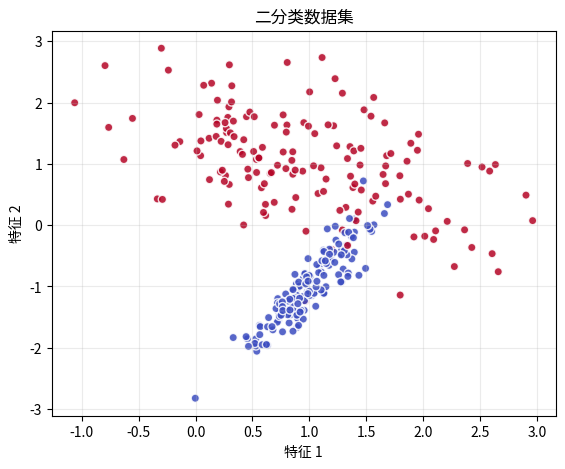

In [8]:
# 生成二分类数据
np.random.seed(42)
X, y = make_classification(
    n_samples=300,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    random_state=42,
    n_clusters_per_class=1,
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"训练集: {X_train.shape[0]} 样本, {X_train.shape[1]} 特征")
print(f"测试集: {X_test.shape[0]} 样本")
print(f"正类比例: {y_train.mean():.2%}")

plt.figure(figsize=(6.5, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=35, edgecolor="white", alpha=0.85)
plt.xlabel("特征 1")
plt.ylabel("特征 2")
plt.title("二分类数据集")
plt.grid(alpha=0.25)
plt.show()

In [9]:
print("--- 开始训练 ---")
model = LogisticRegressionFromScratch(learning_rate=0.1, n_iterations=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("\n--- 测试结果 ---")
print(f"准确率: {accuracy:.4f}")
print(f"学到的权重: w={model.w.round(4)}, b={model.b:.4f}")
assert accuracy > 0.8, f"准确率太低: {accuracy}"
print("✓ 准确率 > 80%，验证通过")

sk_model = LogisticRegression()
sk_model.fit(X_train, y_train)
sk_acc = sk_model.score(X_test, y_test)
print(f"\nsklearn 逻辑回归准确率: {sk_acc:.4f}")
print(f"我们的实现准确率:      {accuracy:.4f}")

--- 开始训练 ---
  Epoch    0: loss=0.6931, accuracy=0.5048
  Epoch  200: loss=0.2102, accuracy=0.9095
  Epoch  400: loss=0.1934, accuracy=0.9095
  Epoch  600: loss=0.1883, accuracy=0.9143
  Epoch  800: loss=0.1860, accuracy=0.9095

--- 测试结果 ---
准确率: 0.9444
学到的权重: w=[0.5429 3.5439], b=-0.2794
✓ 准确率 > 80%，验证通过

sklearn 逻辑回归准确率: 0.9556
我们的实现准确率:      0.9444


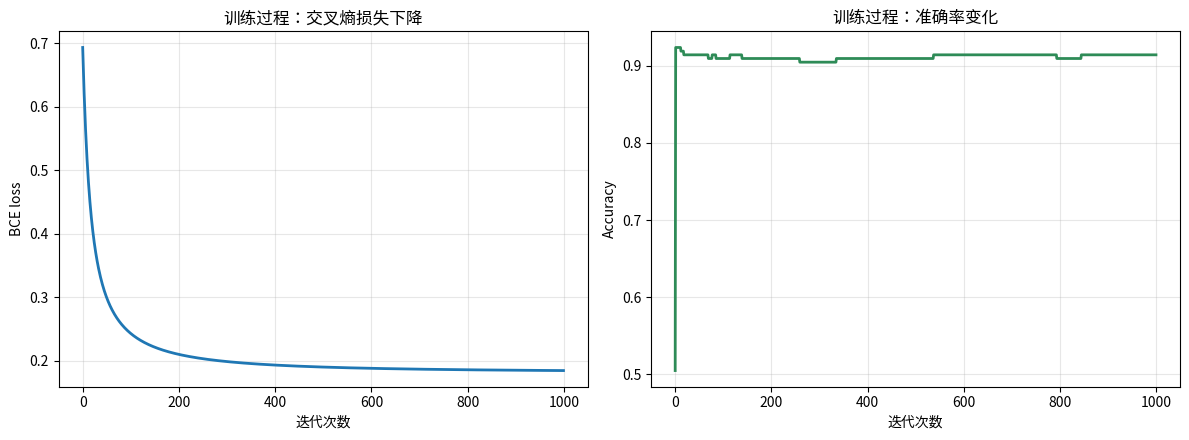

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(model.losses, linewidth=2)
axes[0].set_title("训练过程：交叉熵损失下降")
axes[0].set_xlabel("迭代次数")
axes[0].set_ylabel("BCE loss")
axes[0].grid(alpha=0.3)

axes[1].plot(model.accuracies, linewidth=2, color="seagreen")
axes[1].set_title("训练过程：准确率变化")
axes[1].set_xlabel("迭代次数")
axes[1].set_ylabel("Accuracy")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. 理解决策边界

逻辑回归的决策边界是一条直线（二维中）或超平面（高维中）。

在二维中，默认阈值 $p=0.5$ 对应 $z=0$，所以：

$$w_1x_1+w_2x_2+b=0$$

解出 $x_2$：

$$x_2=-\frac{w_1}{w_2}x_1-\frac{b}{w_2}$$

决策边界一侧预测为正类，另一侧预测为负类。

In [11]:
w1, w2 = model.w
b = model.b
print(f"决策边界方程: {w1:.3f}×x₁ + {w2:.3f}×x₂ + {b:.3f} = 0")
print(f"即: x₂ = {-w1/w2:.3f}×x₁ + {-b/w2:.3f}")

x1_test = 0
x2_boundary = -(w1 / w2) * x1_test - b / w2
z_boundary = w1 * x1_test + w2 * x2_boundary + b
print(f"\n验证: 点 ({x1_test}, {x2_boundary:.4f}) 处的 z = {z_boundary:.6f} (应接近 0)")
assert abs(z_boundary) < 1e-10
print("✓ 验证通过")

决策边界方程: 0.543×x₁ + 3.544×x₂ + -0.279 = 0
即: x₂ = -0.153×x₁ + 0.079

验证: 点 (0, 0.0788) 处的 z = 0.000000 (应接近 0)
✓ 验证通过


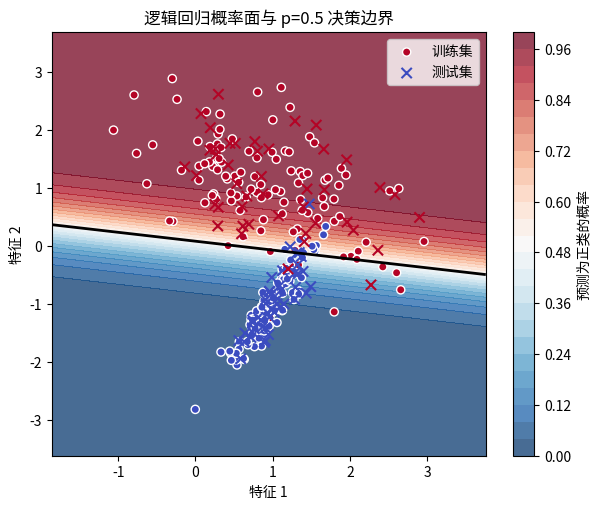

In [12]:
x_min, x_max = X[:, 0].min() - 0.8, X[:, 0].max() + 0.8
y_min, y_max = X[:, 1].min() - 0.8, X[:, 1].max() + 0.8
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250), np.linspace(y_min, y_max, 250))
grid = np.column_stack([xx.ravel(), yy.ravel()])
proba_grid = model.predict_proba(grid).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(7, 5.5))
cont = ax.contourf(xx, yy, proba_grid, levels=30, cmap="RdBu_r", alpha=0.75)
ax.contour(xx, yy, proba_grid, levels=[0.5], colors="black", linewidths=2)
ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="coolwarm", s=35, edgecolor="white", label="训练集")
ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap="coolwarm", marker="x", s=55, label="测试集")
ax.set_xlabel("特征 1")
ax.set_ylabel("特征 2")
ax.set_title("逻辑回归概率面与 p=0.5 决策边界")
ax.legend(loc="upper right")
fig.colorbar(cont, ax=ax, label="预测为正类的概率")
plt.show()

### 阈值不一定必须是 0.5

默认阈值 0.5 很常见，但不是唯一选择。

- 疾病筛查更怕漏诊，可能降低阈值，提高召回率。
- 垃圾邮件过滤更怕误杀正常邮件，可能提高阈值，提高精确率。

阈值变化不会重新训练模型，只会改变“概率如何转成类别”。

In [13]:
print(f"{'阈值':<8} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1':<10}")
print("-" * 52)
for threshold in [0.2, 0.3, 0.5, 0.7, 0.8]:
    pred_t = model.predict(X_test, threshold=threshold)
    print(
        f"{threshold:<8.1f} "
        f"{accuracy_score(y_test, pred_t):<10.4f} "
        f"{precision_score(y_test, pred_t):<10.4f} "
        f"{recall_score(y_test, pred_t):<10.4f} "
        f"{f1_score(y_test, pred_t):<10.4f}"
    )

print("\n阈值 0.5 的混淆矩阵 [[TN, FP], [FN, TP]]:")
print(confusion_matrix(y_test, model.predict(X_test)))

阈值       Accuracy   Precision  Recall     F1        
----------------------------------------------------
0.2      0.8778     0.8113     0.9773     0.8866    
0.3      0.9111     0.8750     0.9545     0.9130    
0.5      0.9444     0.9333     0.9545     0.9438    
0.7      0.9333     0.9750     0.8864     0.9286    
0.8      0.9000     0.9730     0.8182     0.8889    

阈值 0.5 的混淆矩阵 [[TN, FP], [FN, TP]]:
[[43  3]
 [ 2 42]]


## 6. 多类分类：Softmax 回归

二分类用 Sigmoid 输出一个概率。多分类需要输出 $K$ 个类别概率，并且概率和为 1。Softmax 定义为：

$$p_k=\frac{e^{z_k}}{\sum_j e^{z_j}}$$

在 Softmax 回归中：

- $W$ 的形状是 `[n_features, n_classes]`。
- 每个类别有一组权重。
- 输出的每一行是一个概率分布。

代码里为了数值稳定，会先减去每行最大值：`z - np.max(z, axis=1, keepdims=True)`。

In [14]:
scores = np.array([
    [1.0, 2.0, 0.5],
    [0.1, 0.2, 3.0],
])
exp_scores = np.exp(scores - np.max(scores, axis=1, keepdims=True))
probs = exp_scores / exp_scores.sum(axis=1, keepdims=True)
print("类别打分:")
print(scores)
print("Softmax 概率:")
print(probs.round(4))
print("每行概率和:", probs.sum(axis=1).round(4))

类别打分:
[[1.  2.  0.5]
 [0.1 0.2 3. ]]
Softmax 概率:
[[0.2312 0.6285 0.1402]
 [0.0493 0.0545 0.8962]]
每行概率和: [1. 1.]


In [15]:
class SoftmaxRegression:
    """多分类 Softmax 回归"""

    def __init__(self, lr=0.1, n_iter=1000):
        self.lr = lr
        self.n_iter = n_iter

    def softmax(self, z):
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / exp_z.sum(axis=1, keepdims=True)

    def one_hot(self, y, n_classes):
        one_hot = np.zeros((len(y), n_classes))
        one_hot[np.arange(len(y)), y] = 1
        return one_hot

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.n_classes = len(np.unique(y))

        self.W = np.zeros((n_features, self.n_classes))
        self.b = np.zeros(self.n_classes)

        y_onehot = self.one_hot(y, self.n_classes)

        for i in range(self.n_iter):
            z = X @ self.W + self.b
            probs = self.softmax(z)

            error = probs - y_onehot
            dW = (1 / n_samples) * X.T @ error
            db = (1 / n_samples) * error.sum(axis=0)

            self.W -= self.lr * dW
            self.b -= self.lr * db

            if i % 200 == 0:
                loss = -np.mean(np.sum(y_onehot * np.log(probs + 1e-15), axis=1))
                acc = np.mean(np.argmax(probs, axis=1) == y)
                print(f"  Epoch {i:4d}: loss={loss:.4f}, accuracy={acc:.4f}")

        return self

    def predict(self, X):
        z = X @ self.W + self.b
        probs = self.softmax(z)
        return np.argmax(probs, axis=1)

In [16]:
X_multi, y_multi = make_blobs(n_samples=300, centers=3, n_features=2, random_state=42)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.3, random_state=42
)

mean = X_train_m.mean(axis=0)
std = X_train_m.std(axis=0)
X_train_m = (X_train_m - mean) / std
X_test_m = (X_test_m - mean) / std

print("--- 3分类 Softmax 回归 ---")
print("类别数: 3, 特征数: 2")
softmax_model = SoftmaxRegression(lr=0.5, n_iter=1000)
softmax_model.fit(X_train_m, y_train_m)

y_pred_m = softmax_model.predict(X_test_m)
acc_multi = accuracy_score(y_test_m, y_pred_m)
print(f"\n测试准确率: {acc_multi:.4f}")
assert acc_multi > 0.85
print("✓ 多分类准确率 > 85%，验证通过")

--- 3分类 Softmax 回归 ---
类别数: 3, 特征数: 2
  Epoch    0: loss=1.0986, accuracy=0.3381
  Epoch  200: loss=0.0114, accuracy=1.0000
  Epoch  400: loss=0.0060, accuracy=1.0000
  Epoch  600: loss=0.0041, accuracy=1.0000
  Epoch  800: loss=0.0031, accuracy=1.0000

测试准确率: 1.0000
✓ 多分类准确率 > 85%，验证通过


## 7. 逻辑回归的局限性

逻辑回归的决策边界是线性的。对于非线性可分的数据，它表现会受限。

月牙形数据就是典型例子：两类样本像两个月牙一样交错，一条直线很难分开它们。

这也是为什么我们需要后续学习神经网络：神经网络通过多层非线性变换，可以学到复杂决策边界。

In [17]:
X_moon, y_moon = make_moons(n_samples=300, noise=0.2, random_state=42)
X_train_nl, X_test_nl, y_train_nl, y_test_nl = train_test_split(
    X_moon, y_moon, test_size=0.3, random_state=42
)

lr_model = LogisticRegressionFromScratch(learning_rate=0.5, n_iterations=1000)
print("在非线性数据(月牙形)上训练:")
lr_model.fit(X_train_nl, y_train_nl)
y_pred_nl = lr_model.predict(X_test_nl)
acc_nl = accuracy_score(y_test_nl, y_pred_nl)
print(f"\n逻辑回归在非线性数据上的准确率: {acc_nl:.4f}")
print(f"→ 只有 ~{acc_nl*100:.0f}%，因为线性决策边界无法分开月牙形数据")
print("→ 这个问题将在下一章用神经网络解决!")

在非线性数据(月牙形)上训练:
  Epoch    0: loss=0.6931, accuracy=0.4667
  Epoch  200: loss=0.3087, accuracy=0.8476
  Epoch  400: loss=0.3032, accuracy=0.8619
  Epoch  600: loss=0.3025, accuracy=0.8667
  Epoch  800: loss=0.3023, accuracy=0.8667

逻辑回归在非线性数据上的准确率: 0.9000
→ 只有 ~90%，因为线性决策边界无法分开月牙形数据
→ 这个问题将在下一章用神经网络解决!


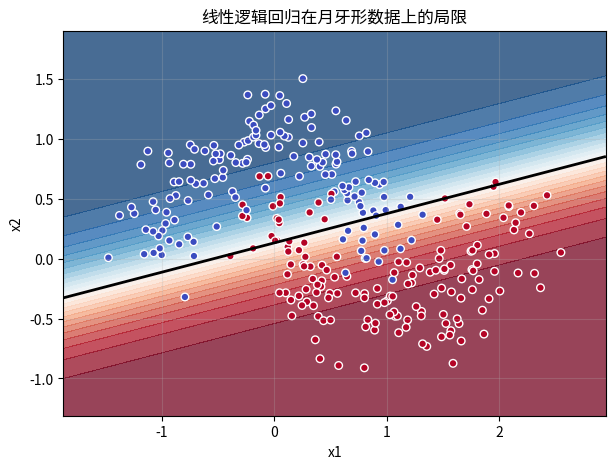

In [18]:
x_min, x_max = X_moon[:, 0].min() - 0.4, X_moon[:, 0].max() + 0.4
y_min, y_max = X_moon[:, 1].min() - 0.4, X_moon[:, 1].max() + 0.4
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250), np.linspace(y_min, y_max, 250))
grid = np.column_stack([xx.ravel(), yy.ravel()])
proba = lr_model.predict_proba(grid).reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, proba, levels=30, cmap="RdBu_r", alpha=0.75)
plt.contour(xx, yy, proba, levels=[0.5], colors="black", linewidths=2)
plt.scatter(X_moon[:, 0], X_moon[:, 1], c=y_moon, cmap="coolwarm", s=30, edgecolor="white")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("线性逻辑回归在月牙形数据上的局限")
plt.grid(alpha=0.25)
plt.show()

## 8. 本节总结

关键要点：

1. 逻辑回归 = 线性打分 + Sigmoid，输出正类概率。
2. 交叉熵比 MSE 更适合分类，尤其会惩罚错误且自信的预测。
3. 梯度核心是 $p-y$，可以理解为概率误差。
4. 决策边界默认是 $p=0.5$ 的位置，二维中是一条直线。
5. 多分类使用 Softmax，把多个类别打分变成概率分布。
6. 逻辑回归只能直接学习线性边界，复杂非线性问题需要特征工程或神经网络。

### 检查题

1. 为什么 $z=0$ 时 Sigmoid 输出 0.5？
2. 真实标签是 1，模型预测概率是 0.01，交叉熵为什么很大？
3. 降低分类阈值通常会让 Recall 上升还是下降？
4. Softmax 输出为什么每一行加起来等于 1？
5. 为什么月牙形数据上线性逻辑回归表现有限？

下一节：决策树与随机森林。它们不用一条直线划分空间，而是通过一系列 if-else 条件切分数据。